In [1]:
import torch
from torch import Tensor, nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import einops
from einops import einsum

import numpy
import random
import matplotlib.pyplot as plt
import plotly.express as px

from tqdm.auto import tqdm
from pprint import pprint
from collections import defaultdict
from dataclasses import dataclass
from typing import Any, Callable, Literal, TypeAlias
from jaxtyping import Float, Int

from plot_support import plot_feature_vectors, plot_interference_matrices

In [2]:
def linear_lr(step, steps):
    return 1-(step/steps)

def constant_lr(*_):
    return 1.0

def cosine_decay_lr(step, steps):
    return np.cos((0.5*np.pi*step) / (step-1))

In [3]:
@dataclass
class ToyModelConfig:
    n_inst: int
    n_features: int=5
    d_hidden: int=2
    n_correlated_pairs: int=0
    n_anticorrelated_pairs: int=0
    feat_mag_distn: Literal["unif", "normal"]="unif"

In [13]:
class ToyModel(nn.Module):
    """
    linear map for a single instance:
        h = ReLU(W @ x)    # additional activation on the bottleneck
        x' = ReLU(W.T @ h + b_final)
    """
    W: Float[Tensor, "n_inst d_hidden n_features"]
    b_final: Float[Tensor, "n_inst n_features"]

    def __init__(self,
                 cfg: ToyModelConfig,
                 feature_probability: float|Tensor=0.01,
                 importance: float|Tensor=1.0,
                 device="cuda",
                ):
        super(ToyModel, self).__init__()
        self.cfg = cfg

        if isinstance(feature_probability, float):
            feature_probability = torch.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        if isinstance(importance, float):
            importance = torch.tensor(importance)
        self.importance = importance.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        self.W = nn.Parameter(
            nn.init.xavier_normal_(torch.empty((cfg.n_inst, cfg.n_features, cfg.d_hidden)))
        )
        self.b_final = nn.Parameter(
            torch.zeros((cfg.n_inst, cfg.n_features))
        )
        self.device = device
        self.to(device)

    
    def forward(
        self,
        features: Float[Tensor, "... n_inst n_features"],
    ) -> Float[Tensor, "... n_inst n_features"]:

        enc = F.relu(
            einsum(
                features,
                self.W,
                "... n_inst n_features, n_inst n_features d_hidden -> ... n_inst d_hidden",
            )
        )
        
        dec = einsum(
            enc,
            self.W,
            "... n_inst d_hidden, n_inst n_features d_hidden -> ... n_inst n_features",
        )
        out = F.relu(dec + self.b_final)

        return out

    
    def generate_batch(
        self,
        batch_size: int=32,
    ) -> Float[Tensor, "batch n_inst n_features"]:

        batch_shape = (batch_size, self.cfg.n_inst, self.cfg.n_features)
        feature_mag = torch.rand(batch_shape, device=self.device)
        # feature_prob = torch.rand(batch_size, device=self.device)
        feature_prob = torch.rand(batch_size, self.cfg.n_inst, self.cfg.n_features, device=self.device)

        return torch.where(feature_prob <= self.feature_probability, feature_mag, 0.0)

    
    def calculate_loss(
        self,
        out: Float[Tensor, "batch n_inst n_features"],
        batch: Float[Tensor, "batch n_inst n_features"],
    ) -> Float[Tensor, ""]:
        
        error = self.importance * ((batch - out) ** 2)
        loss = einops.reduce(error, "batch n_inst n_features -> n_inst", "mean").sum()
        
        return loss

    def optimize(
        self,
        batch_size: int=1024,
        steps: int=5000,
        log_freq: int=50,
        lr: float=1e-3,
        lr_scale: Callable[[int, int], float]=constant_lr,
    ):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        progress_bar = tqdm(range(steps))
        
        for step in progress_bar:
            step_lr = lr*lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(loss=loss.item() / self.cfg.n_inst, lr=step_lr)


In [14]:
toymodelcfg = ToyModelConfig(n_inst=8, n_features=5, d_hidden=2)
importance = 0.9 ** torch.arange(toymodelcfg.n_features)
print(importance)
feature_probability = 50 ** -torch.linspace(0, 1, toymodelcfg.n_inst)
print(feature_probability)

tensor([1.0000, 0.9000, 0.8100, 0.7290, 0.6561])
tensor([1.0000, 0.5719, 0.3270, 0.1870, 0.1069, 0.0612, 0.0350, 0.0200])


In [15]:
toymodel = ToyModel(
    cfg=toymodelcfg,
    device="cuda",
    importance=importance[None, :],
    feature_probability=feature_probability[:, None]
)

toymodel.optimize()

  0%|          | 0/5000 [00:00<?, ?it/s]

In [16]:
bc_importance = torch.broadcast_to(importance, (toymodelcfg.n_inst, toymodelcfg.n_features))
W_detached = toymodel.W.cpu().detach()

tensor([1.0000, 0.5719, 0.3270, 0.1870, 0.1069, 0.0612, 0.0350, 0.0200])


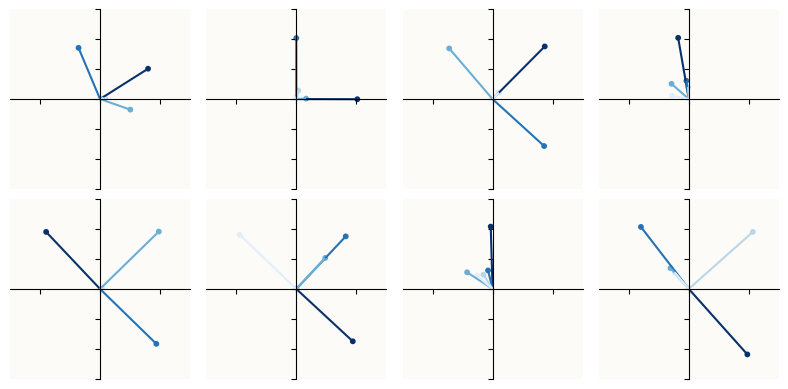

In [17]:
print(feature_probability)
plot_feature_vectors(data=W_detached, importance=bc_importance)

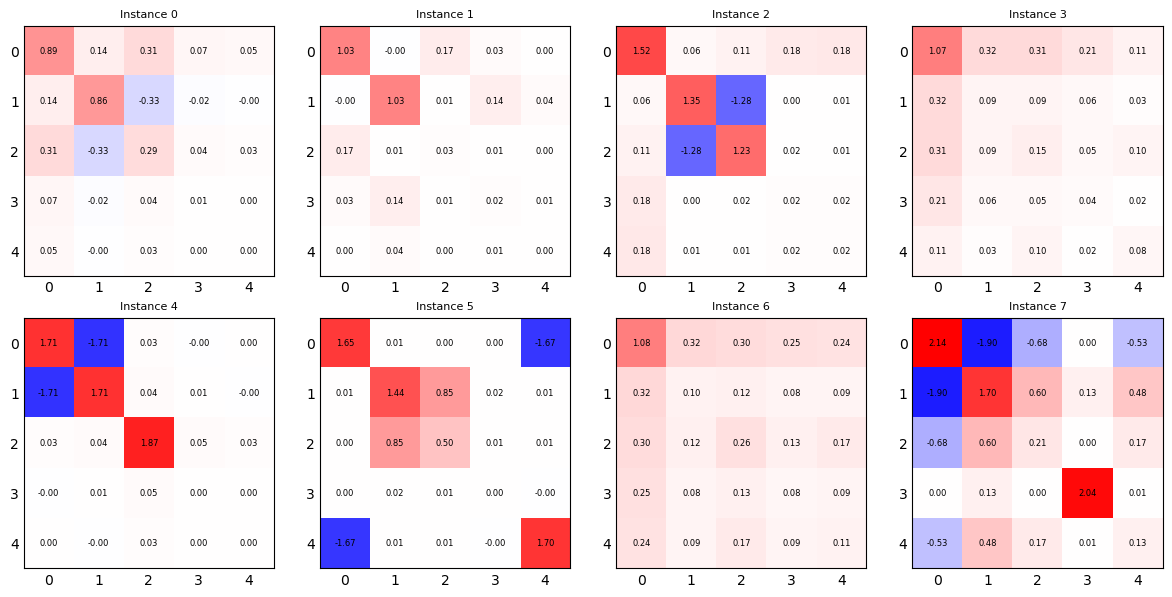

In [18]:
plot_interference_matrices(W_detached)